In [1]:
# ============================================
# SALES & BUSINESS ANALYTICS PROJECT
# Dataset Generation
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

# Products
products = [
    "Laptop",
    "Mobile",
    "Headphones",
    "Keyboard",
    "Monitor",
    "Mouse",
    "Tablet",
    "Printer"
]

# Categories
categories = {
    "Laptop": "Electronics",
    "Mobile": "Electronics",
    "Headphones": "Electronics",
    "Keyboard": "Accessories",
    "Monitor": "Electronics",
    "Mouse": "Accessories",
    "Tablet": "Electronics",
    "Printer": "Office"
}

regions = ["North", "South", "East", "West"]

# Generate dates
dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")

data = []

for i in range(500):

    product = np.random.choice(products)
    category = categories[product]
    region = np.random.choice(regions)

    date = np.random.choice(dates)

    quantity = np.random.randint(1, 6)

    # Product price
    if product == "Laptop":
        price = np.random.randint(45000, 80000)
    elif product == "Mobile":
        price = np.random.randint(15000, 60000)
    elif product == "Tablet":
        price = np.random.randint(12000, 40000)
    elif product == "Monitor":
        price = np.random.randint(8000, 25000)
    elif product == "Printer":
        price = np.random.randint(6000, 20000)
    elif product == "Headphones":
        price = np.random.randint(1000, 8000)
    elif product == "Keyboard":
        price = np.random.randint(700, 4000)
    else:
        price = np.random.randint(500, 3000)

    sales = quantity * price

    # Cost between 60% and 85% of sales
    cost = sales * np.random.uniform(0.60, 0.85)

    profit = sales - cost

    data.append([
        date,
        product,
        category,
        region,
        quantity,
        price,
        sales,
        cost,
        profit
    ])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "Date",
    "Product",
    "Category",
    "Region",
    "Quantity",
    "Unit_Price",
    "Sales",
    "Cost",
    "Profit"
])

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

print("Dataset created successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Dataset created successfully!
Rows: 500
Columns: 9


,Date,Product,Category,Region,Quantity,Unit_Price,Sales,Cost,Profit
0,2025-01-01,Mouse,Accessories,East,5,970,4850,2965.103736,1884.896264
1,2025-01-02,Mobile,Electronics,West,2,55757,111514,67781.367624,43732.632376
2,2025-01-03,Mouse,Accessories,North,5,1665,8325,5613.137237,2711.862763
3,2025-01-03,Keyboard,Accessories,North,1,2623,2623,1638.836039,984.163961
4,2025-01-03,Printer,Office,West,5,13446,67230,47049.502255,20180.497745


In [2]:
# ============================================
# DATA CLEANING
# ============================================

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Convert date
df["Date"] = pd.to_datetime(df["Date"])

# Make sure numerical values are positive
df["Quantity"] = df["Quantity"].abs()
df["Unit_Price"] = df["Unit_Price"].abs()
df["Sales"] = df["Sales"].abs()
df["Cost"] = df["Cost"].abs()
df["Profit"] = df["Profit"].abs()

print("\nData cleaning completed.")
print("Final rows:", len(df))

Missing values:
Date          0
Product       0
Category      0
Region        0
Quantity      0
Unit_Price    0
Sales         0
Cost          0
Profit        0
dtype: int64

Duplicate rows: 0

Data cleaning completed.
Final rows: 500


In [3]:
# ============================================
# KEY PERFORMANCE INDICATORS
# ============================================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
average_order_value = df["Sales"].mean()

profit_margin = (total_profit / total_sales) * 100

print("========== BUSINESS KPIs ==========")

print(f"Total Sales       : ₹{total_sales:,.2f}")
print(f"Total Profit      : ₹{total_profit:,.2f}")
print(f"Quantity Sold     : {total_quantity:,}")
print(f"Average Sale      : ₹{average_order_value:,.2f}")
print(f"Profit Margin     : {profit_margin:.2f}%")

========== BUSINESS KPIs ==========
Total Sales       : ₹32,693,513.00
Total Profit      : ₹8,829,846.71
Quantity Sold     : 1,498
Average Sale      : ₹65,387.03
Profit Margin     : 27.01%


In [4]:
# ============================================
# PRODUCT PERFORMANCE
# ============================================

product_analysis = df.groupby("Product").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Quantity_Sold=("Quantity", "sum")
).sort_values("Total_Sales", ascending=False)

print("PRODUCT PERFORMANCE")
display(product_analysis)

PRODUCT PERFORMANCE


,Total_Sales,Total_Profit,Quantity_Sold
Product,,,
Laptop,10542026,2.849919e+06,170
Mobile,9796187,2.642550e+06,242
Tablet,5737511,1.573226e+06,222
Monitor,3206606,8.596895e+05,196
Printer,2041159,5.333407e+05,150
Headphones,551888,1.547359e+05,125
Keyboard,520106,1.335141e+05,217
Mouse,298030,8.287082e+04,176


In [5]:
# ============================================
# REGIONAL PERFORMANCE
# ============================================

region_analysis = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Quantity_Sold=("Quantity", "sum")
).sort_values("Total_Sales", ascending=False)

print("REGIONAL PERFORMANCE")
display(region_analysis)

REGIONAL PERFORMANCE


,Total_Sales,Total_Profit,Quantity_Sold
Region,,,
West,9468211,2.643939e+06,354
North,9222603,2.397016e+06,401
East,7933517,2.192551e+06,373
South,6069182,1.596341e+06,370


In [6]:
# ============================================
# CATEGORY PERFORMANCE
# ============================================

category_analysis = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Quantity_Sold=("Quantity", "sum")
).sort_values("Total_Sales", ascending=False)

print("CATEGORY PERFORMANCE")
display(category_analysis)

CATEGORY PERFORMANCE


,Total_Sales,Total_Profit,Quantity_Sold
Category,,,
Electronics,29834218,8.080121e+06,955
Office,2041159,5.333407e+05,150
Accessories,818136,2.163850e+05,393


In [7]:
# ============================================
# MONTHLY SALES TREND
# ============================================

df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_analysis = df.groupby("Month").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

print("MONTHLY PERFORMANCE")
display(monthly_analysis)

MONTHLY PERFORMANCE


,Total_Sales,Total_Profit
Month,,
2025-01,1832898,511851.667918
2025-02,2708367,731263.322052
2025-03,3762643,945732.355386
2025-04,2698630,702623.640233
2025-05,2893428,897134.193074
2025-06,2021700,558884.102030
2025-07,1954520,541220.336570
2025-08,3191507,795235.696606
2025-09,3007748,812225.922224


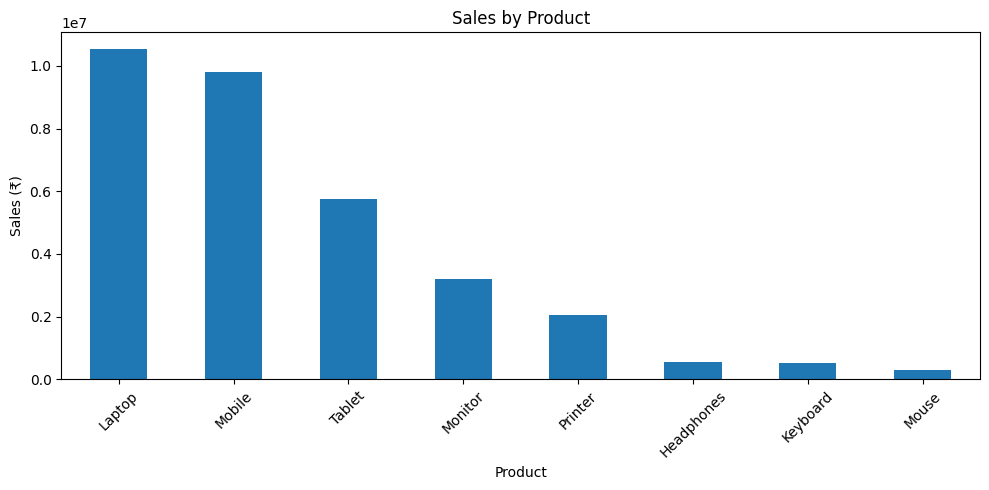

In [8]:
# ============================================
# SALES BY PRODUCT
# ============================================

plt.figure(figsize=(10, 5))

product_analysis["Total_Sales"].plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

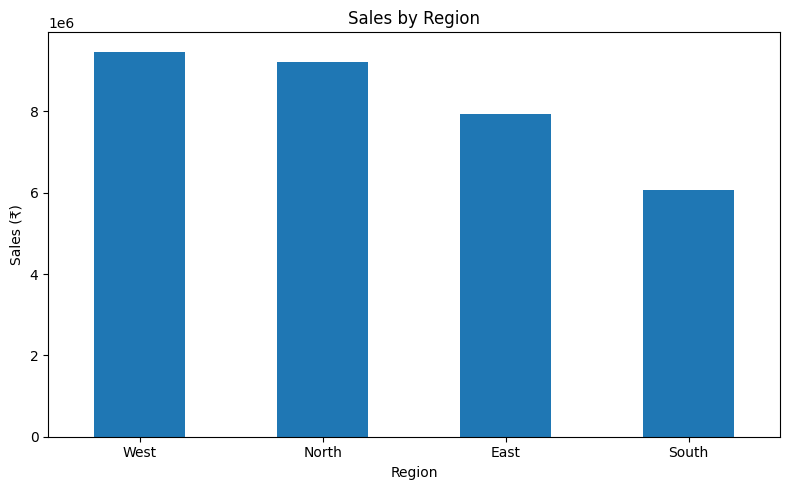

In [9]:
# ============================================
# SALES BY REGION
# ============================================

plt.figure(figsize=(8, 5))

region_analysis["Total_Sales"].plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

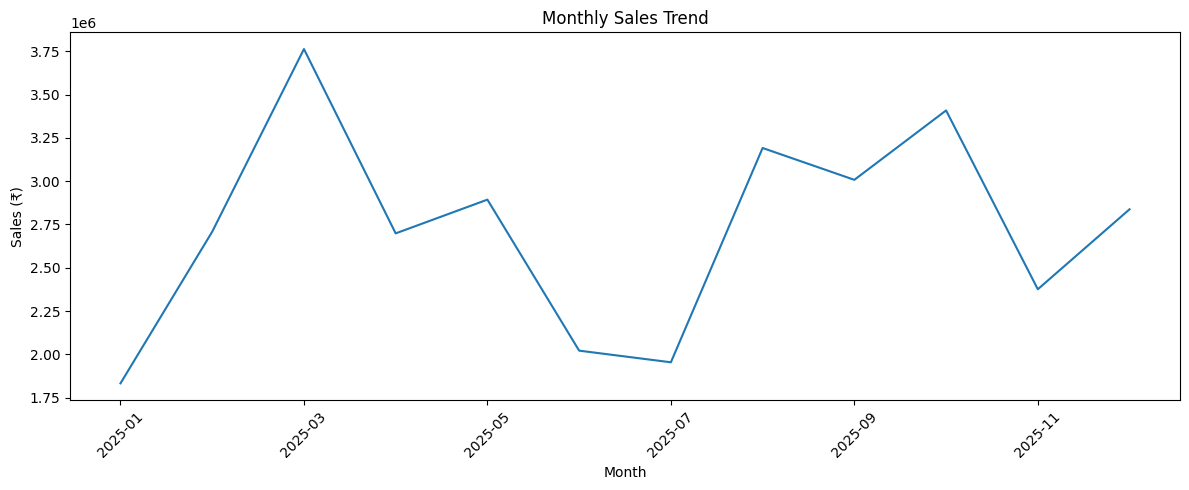

In [10]:
# ============================================
# MONTHLY SALES TREND
# ============================================

plt.figure(figsize=(12, 5))

monthly_analysis["Total_Sales"].plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

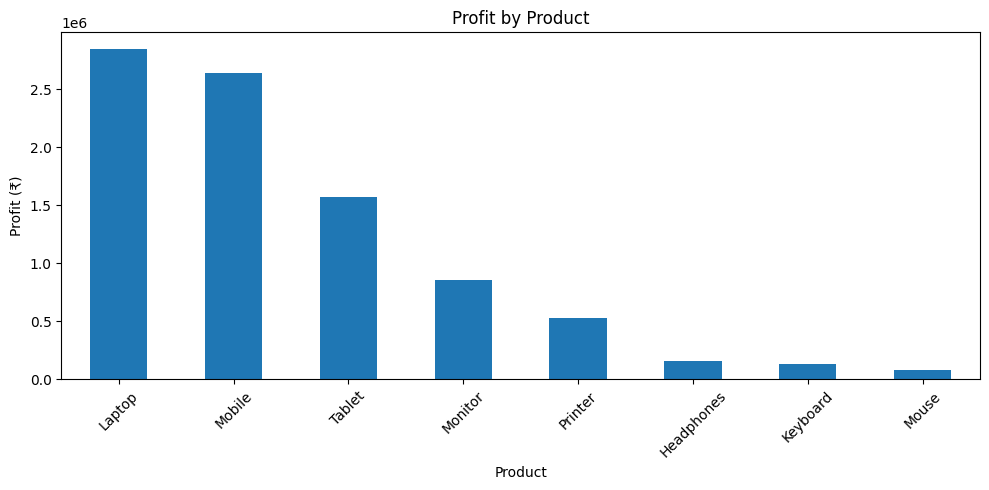

In [11]:
# ============================================
# PROFIT BY PRODUCT
# ============================================

plt.figure(figsize=(10, 5))

product_analysis["Total_Profit"].plot(kind="bar")

plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
# ============================================
# BUSINESS INSIGHTS
# ============================================

best_product = product_analysis["Total_Sales"].idxmax()
best_region = region_analysis["Total_Sales"].idxmax()
best_category = category_analysis["Total_Sales"].idxmax()

most_profitable_product = product_analysis["Total_Profit"].idxmax()

best_month = monthly_analysis["Total_Sales"].idxmax()

print("========== BUSINESS INSIGHTS ==========")

print(f"1. Best performing product: {best_product}")
print(f"2. Highest sales region: {best_region}")
print(f"3. Best performing category: {best_category}")
print(f"4. Most profitable product: {most_profitable_product}")
print(f"5. Highest sales month: {best_month}")

print("\nOverall Profit Margin:")
print(f"{profit_margin:.2f}%")

========== BUSINESS INSIGHTS ==========
1. Best performing product: Laptop
2. Highest sales region: West
3. Best performing category: Electronics
4. Most profitable product: Laptop
5. Highest sales month: 2025-03

Overall Profit Margin:
27.01%


In [13]:
# ============================================
# EXPORT PROJECT FILES
# ============================================

from pathlib import Path

Path("results").mkdir(exist_ok=True)

# Main dataset
df.to_csv("sales_data.csv", index=False)

# Analysis results
product_analysis.to_csv(
    "results/product_analysis.csv"
)

region_analysis.to_csv(
    "results/region_analysis.csv"
)

category_analysis.to_csv(
    "results/category_analysis.csv"
)

monthly_analysis.to_csv(
    "results/monthly_sales.csv"
)

print("====================================")
print("PROJECT FILES CREATED SUCCESSFULLY")
print("====================================")

print("""
sales_data.csv

results/
    product_analysis.csv
    region_analysis.csv
    category_analysis.csv
    monthly_sales.csv
""")

PROJECT FILES CREATED SUCCESSFULLY

sales_data.csv

results/
    product_analysis.csv
    region_analysis.csv
    category_analysis.csv
    monthly_sales.csv



In [14]:
# ============================================
# PROJECT SUMMARY
# ============================================

summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Quantity Sold",
        "Average Sale",
        "Profit Margin",
        "Best Product",
        "Best Region",
        "Best Category",
        "Best Sales Month"
    ],
    "Value": [
        f"₹{total_sales:,.2f}",
        f"₹{total_profit:,.2f}",
        f"{total_quantity:,}",
        f"₹{average_order_value:,.2f}",
        f"{profit_margin:.2f}%",
        best_product,
        best_region,
        best_category,
        best_month
    ]
})

display(summary)

summary.to_csv(
    "results/project_summary.csv",
    index=False
)

,Metric,Value
0,Total Sales,"₹32,693,513.00"
1,Total Profit,"₹8,829,846.71"
2,Quantity Sold,"1,498"
3,Average Sale,"₹65,387.03"
4,Profit Margin,27.01%
5,Best Product,Laptop
6,Best Region,West
7,Best Category,Electronics
8,Best Sales Month,2025-03
